In [1]:
import torch
import sys
from pathlib import Path

from mst.models.dino import DinoV2ClassifierSlice
from mst_xai.xai_methods.gradcam import GradCAM_MST
from mst.data.datasets.dataset_3d_odelia import ODELIA_Dataset3D
from mst.inference.predictor import load_model
import torch.nn.functional as F


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

/home/jovyan/work/MST/mst/models/extern/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/jovyan/work/MST/mst/models/extern/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/jovyan/work/MST/mst/models/extern/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

run_dir = Path("/home/jovyan/work/MST/runs")

# run_folder = Path("ODELIA/DinoV2ClassifierSlice_Final")
# path_run = run_dir / run_folder

##For New Model
run_folder = Path("DINOv3ViTB")
checkpoint_name = "challenge_mstv3-vit_sch_CB_sub2_best.chkpt"
path_run = run_dir / run_folder / checkpoint_name

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("DinoV2ClassifierSlice", path_run, device)
model.to(device)
model.eval()


Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


DinoV2ClassifierSlice(
  (loss_func): CrossEntropyLoss()
  (auc_roc): ModuleDict(
    (train_): MulticlassAUROC()
    (val_): MulticlassAUROC()
    (test_): MulticlassAUROC()
  )
  (acc): ModuleDict(
    (train_): MulticlassAccuracy()
    (val_): MulticlassAccuracy()
    (test_): MulticlassAccuracy()
  )
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): Layer

In [3]:
ds = ODELIA_Dataset3D(split="test", path_root="/home/jovyan/work/MST/mst/data/datasets/ODELIA_datasets")

sample = ds[22]   # single sample
uid = sample["uid"]
gt = int(sample["target"])

print("UID:", uid, "GT:", gt)


UID: ODELIA_TRICKS_0091_1_right GT: 2


In [4]:
batch = {
    "source": sample["source"].unsqueeze(0).to(device),
    "target": torch.tensor([gt], device=device)
}


In [5]:
batch.keys()

dict_keys(['source', 'target'])

In [6]:
print(f"source size = {batch['source'].shape}")
# expected: [1, 1, D, H, W]


source size = torch.Size([1, 1, 32, 224, 224])


## Test Activations and Gradients

#### Define Target layer

In [7]:
target_layer = model.encoder.blocks[-1].norm1

#### Define Function - Extra token

In [8]:
def _get_num_extra_tokens(source):
    """
    This method detects how many extra tokens (beyond the CLS token) are present in the ViT encoder's output.        
    # Remove CLS + extra tokens (we only want patch tokens for spatial saliency)
    # ViT tokes = [CLS] + [extra tokens] + [patch tokens]
    # For DinoV2, there are possible to have only 1 CLS toke or extra register tokens,
    # For DinoV3, there are possible to have 1 CLS token + 4 storage tokens
    """

    # No gradient needed -> just inspect model structure to determine how many extra tokens there are (e.g., CLS + storage tokens)
    with torch.no_grad():
        # Take one slice for probing
        x_enc = source[:1]              # (1,1,D,H,W)
        x_enc = x_enc[:, :, 0]          # take one slice → (1,1,H,W)
        # Convert to 3-channel by repeating the single channel (ViT requires 3-channel input) → (1,3,H,W)
        x_enc = x_enc.repeat(1, 3, 1, 1)  # → (1,3,H,W)

        # Get token structure
        out = model.encoder.forward_features(x_enc)

    # Detect exttra tokens based on the output of the encoder's forward_features method.
    # If new models have different token structures, this logic may need to be updated.
    if "x_storage_tokens" in out:
        # DinoV3 (CLS + storage tokens)
        num_extra_tokens = out["x_storage_tokens"].shape[1] 
    elif "x_norm_regtokens" in out:
        # DinoV2 (CLS + normalized register tokens)
        num_extra_tokens = out["x_norm_regtokens"].shape[1]
    else:
        # Default to 0 if no extra tokens are detected (only CLS token)
        num_extra_tokens = 0

    return num_extra_tokens

def _remove_extra_tokens(acts, grads, source):
    num_extra_tokens = _get_num_extra_tokens(source)
    # Remove CLS and extra tokens from activations and gradients to focus on patch tokens
    acts = acts[:, 1 + num_extra_tokens:, :] # 1+num_extra_tokens to skip CLS and extra tokens
    grads = grads[:, 1 + num_extra_tokens:, :]
    return acts, grads

#### Explore acts and grads

In [9]:
from pytorch_grad_cam.activations_and_gradients import ActivationsAndGradients
activations_and_grads = ActivationsAndGradients(
    model=model,
    target_layers=[target_layer],
    reshape_transform=None
)

In [10]:
B, C, D, H, W = batch["source"].shape
print(batch["source"].shape)
print(f"Batch dimensions B: {B}, C: {C}, D: {D}, H: {H}, W: {W}")

torch.Size([1, 1, 32, 224, 224])
Batch dimensions B: 1, C: 1, D: 32, H: 224, W: 224


In [11]:
# Get patch size from the model
patch_size = model.encoder.patch_embed.patch_size
print(type(patch_size), patch_size)

# get patch size (square patches)
patch_size = patch_size[0]
print(f"Patch size: {patch_size}")

<class 'tuple'> (16, 16)
Patch size: 16


In [12]:
logits = activations_and_grads(batch["source"])
# logits = model(batch["source"])
print(f"logits values: {logits}")
print(logits.shape)  

logits values: tensor([[ 0.4814, -0.3423,  1.6294]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
torch.Size([1, 3])


In [13]:
pred_class = logits.argmax(dim=1).item()
print("Predicted class:", pred_class)

Predicted class: 2


In [14]:
class_specific_logits = logits[:,pred_class]

In [15]:
# class_specific_logits
model.zero_grad()
class_specific_logits.backward()

In [16]:
acts = activations_and_grads.activations  # (B*D, N, C)
grads = activations_and_grads.gradients 

In [17]:
print(type(acts), len(acts), acts[0].shape)
print(type(grads), len(grads), grads[0].shape)

<class 'list'> 1 torch.Size([32, 201, 768])
<class 'list'> 1 torch.Size([32, 201, 768])


In [18]:
acts = acts[0]
grads = grads[0]

In [19]:
print(type(acts), acts.shape)
print(type(grads), grads.shape)

<class 'torch.Tensor'> torch.Size([32, 201, 768])
<class 'torch.Tensor'> torch.Size([32, 201, 768])


In [20]:
acts, grads = _remove_extra_tokens(acts, grads, batch["source"])

In [21]:
acts.shape, grads.shape # (B*D, N, C)

(torch.Size([32, 196, 768]), torch.Size([32, 196, 768]))

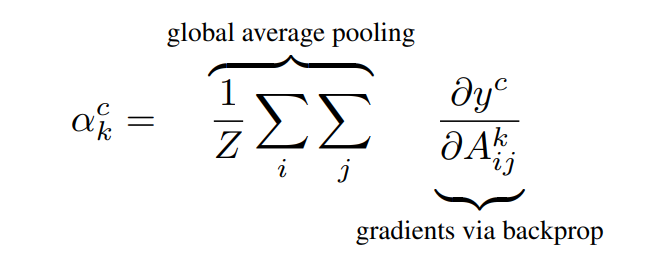

In [22]:
# Average gradients over 196 tokens
# weights = grads.mean(dim=1) # (B*D, C)
weights = grads.mean(dim=(0, 1))  # (C)
print(f"Shape of weights after averaging: {weights.shape}")
# Broadcast weights to match activations for weighted combination
weights = weights.unsqueeze(0).unsqueeze(1)
print(f"Shape of weights after unsqueeze: {weights.shape}")

Shape of weights after averaging: torch.Size([768])
Shape of weights after unsqueeze: torch.Size([1, 1, 768])


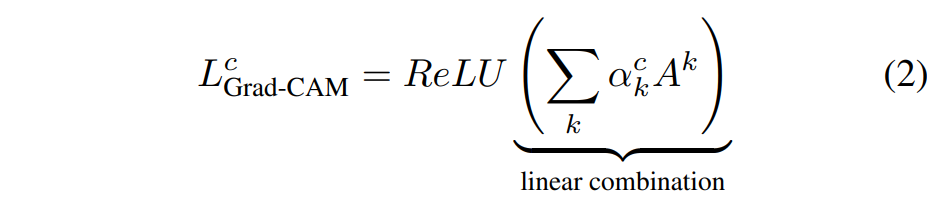

In [23]:
# sum over channels into one value per token
cam = (acts * weights).sum(dim=2)  # (B*D, N) 
print(f"Shape of CAM: {cam.shape}")
print(cam)
cam = torch.relu(cam)
print(cam)  
print(f"Shape of CAM after ReLU: {cam.shape}")  # (B*D, N)

Shape of CAM: torch.Size([32, 196])
tensor([[-8.9930e-05, -1.1873e-04, -1.0843e-04,  ..., -2.0167e-04,
         -6.6430e-05, -8.9409e-05],
        [-8.6521e-05, -4.7039e-05, -9.3060e-05,  ..., -1.3030e-04,
         -3.6515e-05, -8.2865e-05],
        [-6.8721e-05, -7.2275e-05, -8.5540e-05,  ..., -9.5458e-05,
         -9.3241e-05, -6.2147e-05],
        ...,
        [-4.4080e-05, -3.8199e-05,  3.5683e-05,  ..., -6.6906e-05,
         -8.1817e-05, -4.2233e-05],
        [-2.6247e-05, -4.8511e-05,  4.6334e-05,  ..., -8.7128e-05,
         -6.6246e-05, -4.9852e-05],
        [-2.0654e-05, -1.8855e-07,  7.3380e-05,  ...,  1.2871e-06,
         -8.9033e-05, -3.5274e-05]])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [0.0000e+00, 0.0000e

In [24]:
h_p = H // patch_size
w_p = W // patch_size
cam = cam.view(B, D, h_p, w_p)  # Reshape from (B*D, N) to (B, D, h_p, w_p)
print(f"Shape of CAM after reshaping: {cam.shape}")

Shape of CAM after reshaping: torch.Size([1, 32, 14, 14])


In [25]:
cam = F.interpolate(
    cam.unsqueeze(1), # add channel dimension for interpolation to (B, 1, D, h_p, w_p)
    size = (D, H, W), # from (B, 1, D, h_p, w_p) to (B, 1, D, H, W)
    mode = 'trilinear',
    align_corners = False).squeeze(1) # remove channel dimension after interpolation
print(f"Shape of CAM after interpolation: {cam.shape}")

Shape of CAM after interpolation: torch.Size([1, 32, 224, 224])


In [26]:
print(cam)

tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.5103e-06,
           2.5103e-06, 2.5103e-06],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.5103e-06,
           2.5103e-06, 2.5103e-06],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.5103e-06,
           2.5103e-06, 2.5103e-06],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000

In [27]:
cam = cam.squeeze(0)
print(f"Shape of CAM after squeezing batch dimension: {cam.shape}")

# Normalize with min-max normalization per sample
cam = cam - cam.min()
cam = cam / (cam.max() - cam.min() + 1e-8) # add small epsilon to avoid division by zero

print(f"Shape of CAM after normalization: {cam.shape}")

Shape of CAM after squeezing batch dimension: torch.Size([32, 224, 224])
Shape of CAM after normalization: torch.Size([32, 224, 224])


In [28]:
cam_np = cam.detach().cpu().numpy()  # (D, H, W)

#### Visualize

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def overlay_heatmap(image, saliency, alpha=0.5):
    
    image_uint8 = np.uint8(255 * image)
    heatmap_uint8 = np.uint8(255 * saliency)

    heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        heatmap,
        alpha,
        np.stack([image_uint8]*3, axis=-1),
        1-alpha,
        0
    )

    return overlay

def concat_input_overlay(input_2d, overlay_rgb):
    """
    input_2d: (H, W) normalized [0,1]
    overlay_rgb: (H, W, 3) uint8 or float [0,255]
    """
    # convert input to RGB
    input_uint8 = np.uint8(255 * input_2d)
    input_rgb = np.stack([input_uint8]*3, axis=-1)

    # ensure same dtype
    if overlay_rgb.dtype != np.uint8:
        overlay_rgb = np.uint8(overlay_rgb)

    # concatenate horizontally
    combined = np.concatenate([input_rgb, overlay_rgb], axis=1)
    return combined

min_volume :=0.0, max_volume :=1.0
min_saliency :=0.0, max_saliency :=0.9999816417694092


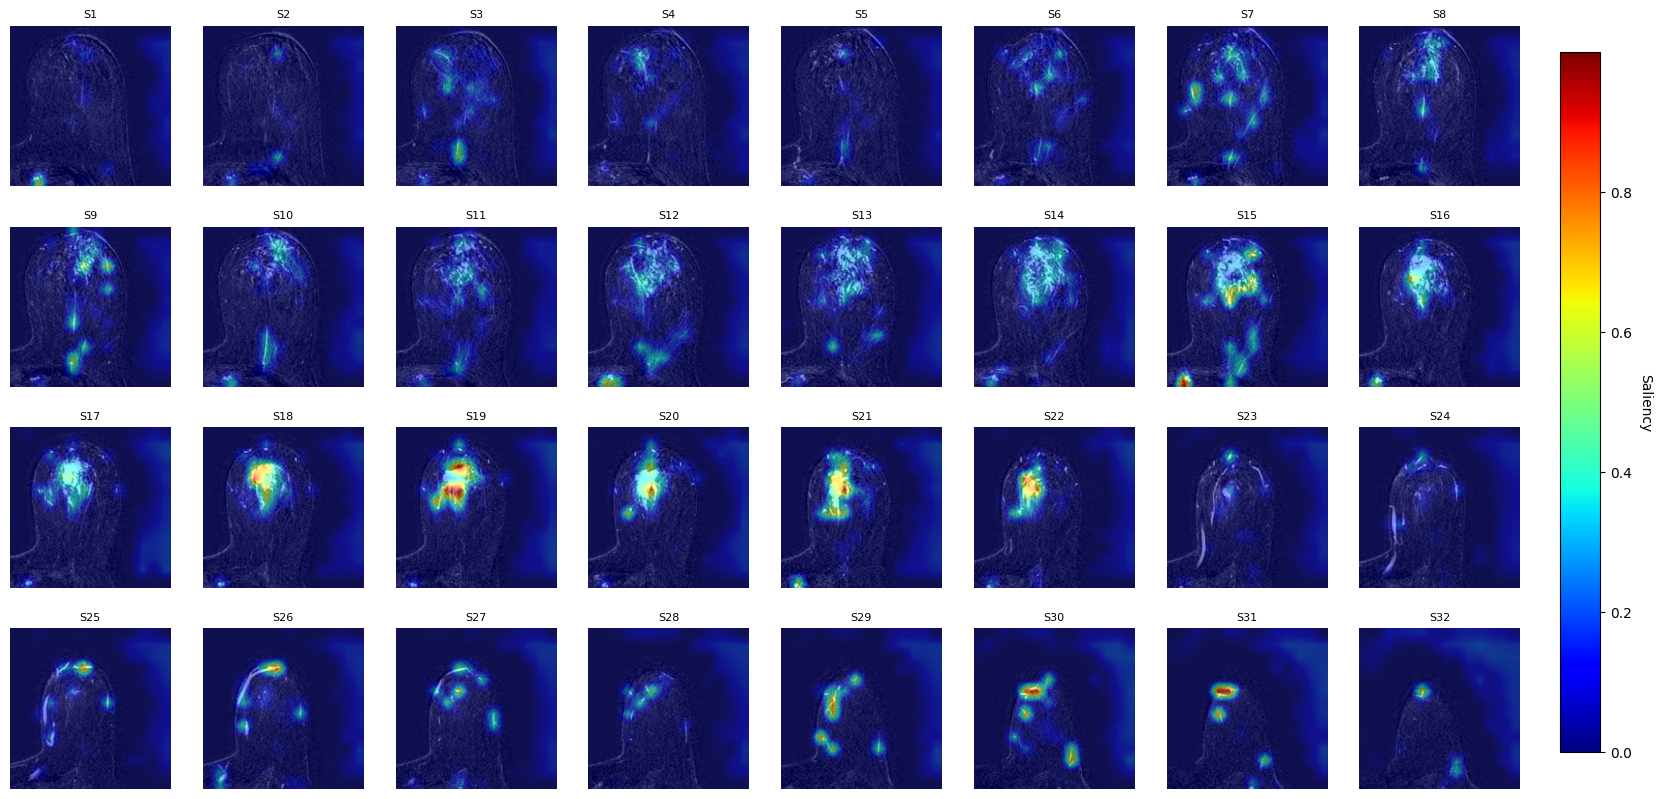

In [30]:
overlays = []
num_slices = batch["source"].shape[2]
volume = batch["source"].squeeze(0).squeeze(0).cpu().numpy()  # (D, H, W)
volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)  # Normalize to [0,1]
print(f"min_volume :={volume.min()}, max_volume :={volume.max()}")
saliency = cam_np  # (D, H, W)
print (f"min_saliency :={saliency.min()}, max_saliency :={saliency.max()}")
for i in range(num_slices):
    overlays.append(
        overlay_heatmap(volume[i], saliency[i])
    )

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(overlays[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

#fig.suptitle(f"{uid} | {class_name} | {method_name}", fontsize=14)

# overlay_path = os.path.join(
#     class_save_root,
#     f"{uid}_{class_name}_{method_name}_overlay.png"
# )

fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.savefig(overlay_path, dpi=150)
plt.show()
plt.close(fig)

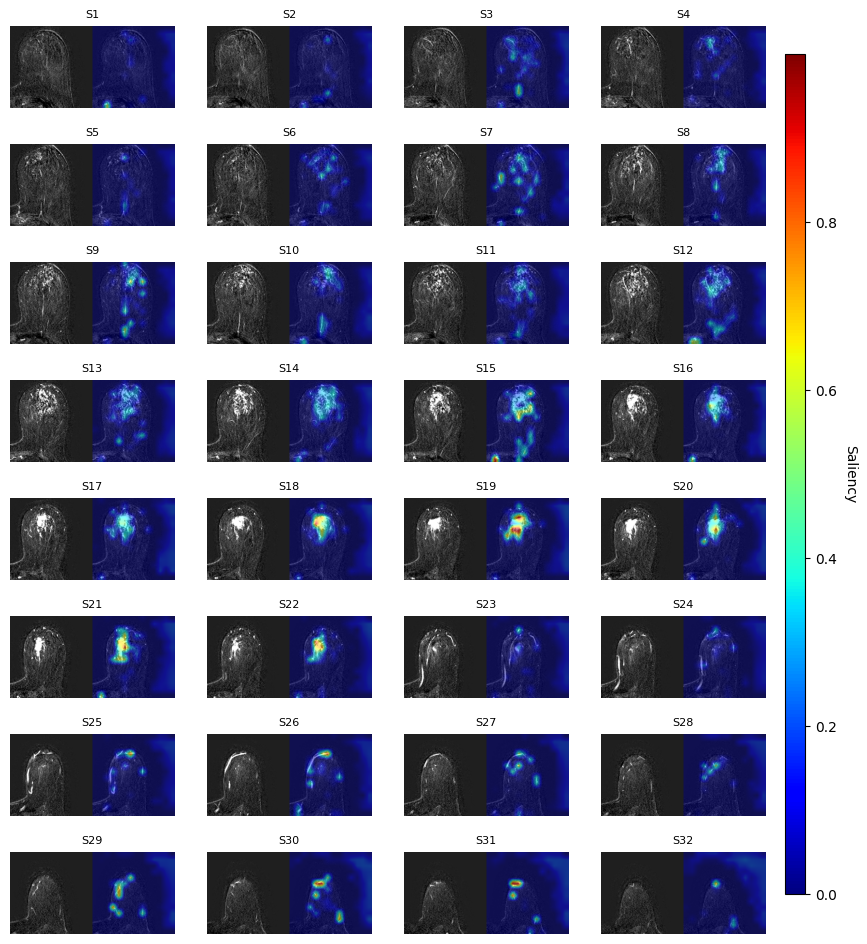

In [31]:
comparisons = []
for i in range(num_slices):

    img = volume[i]
    sal = saliency[i]

    overlay = overlay_heatmap(img, sal)

    img_rgb = np.stack([img]*3, axis=-1)
    # img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)
    img_rgb = np.uint8(255 * img_rgb)

    combined = np.concatenate([img_rgb, overlay], axis=1)
    comparisons.append(combined)

fig, axes = plt.subplots(8, 4, figsize=(10, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(comparisons[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

# fig.suptitle(f"{uid} | {class_name} | {method_name}", fontsize=14)

# comparison_path = os.path.join(
#     class_save_root,
#     f"{uid}_{class_name}_{method_name}_comparison.png"
# )

fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.savefig(comparison_path, dpi=150)
plt.show()
plt.close(fig)

#### Grad-CAM without ReLU

In [32]:
# sum over channels into one value per token
cam = (acts * weights).sum(dim=2)  # (B*D, N) 
#cam = torch.relu(cam)

In [33]:
h_p = H // patch_size
w_p = W // patch_size
cam_no_relu = cam.view(B, D, h_p, w_p)  # Reshape from (B*D, N) to (B, D, h_p, w_p)

cam_no_relu = F.interpolate(
    cam_no_relu.unsqueeze(1), # add channel dimension for interpolation to (B, 1, D, h_p, w_p)
    size = (D, H, W), # from (B, 1, D, h_p, w_p) to (B, 1, D, H, W)
    mode = 'trilinear',
    align_corners = False).squeeze(1) # remove channel dimension after interpolation

cam_no_relu = cam_no_relu.squeeze(0)

# Normalize with min-max normalization per sample
cam_no_relu = cam_no_relu - cam_no_relu.min()
cam_no_relu = cam_no_relu / (cam_no_relu.max() - cam_no_relu.min() + 1e-8) # add small epsilon to avoid division by zero

cam_no_relu_np = cam_no_relu.detach().cpu().numpy()  # (D, H, W)

min_volume :=0.0, max_volume :=1.0
min_saliency :=0.0, max_saliency :=0.9999901056289673


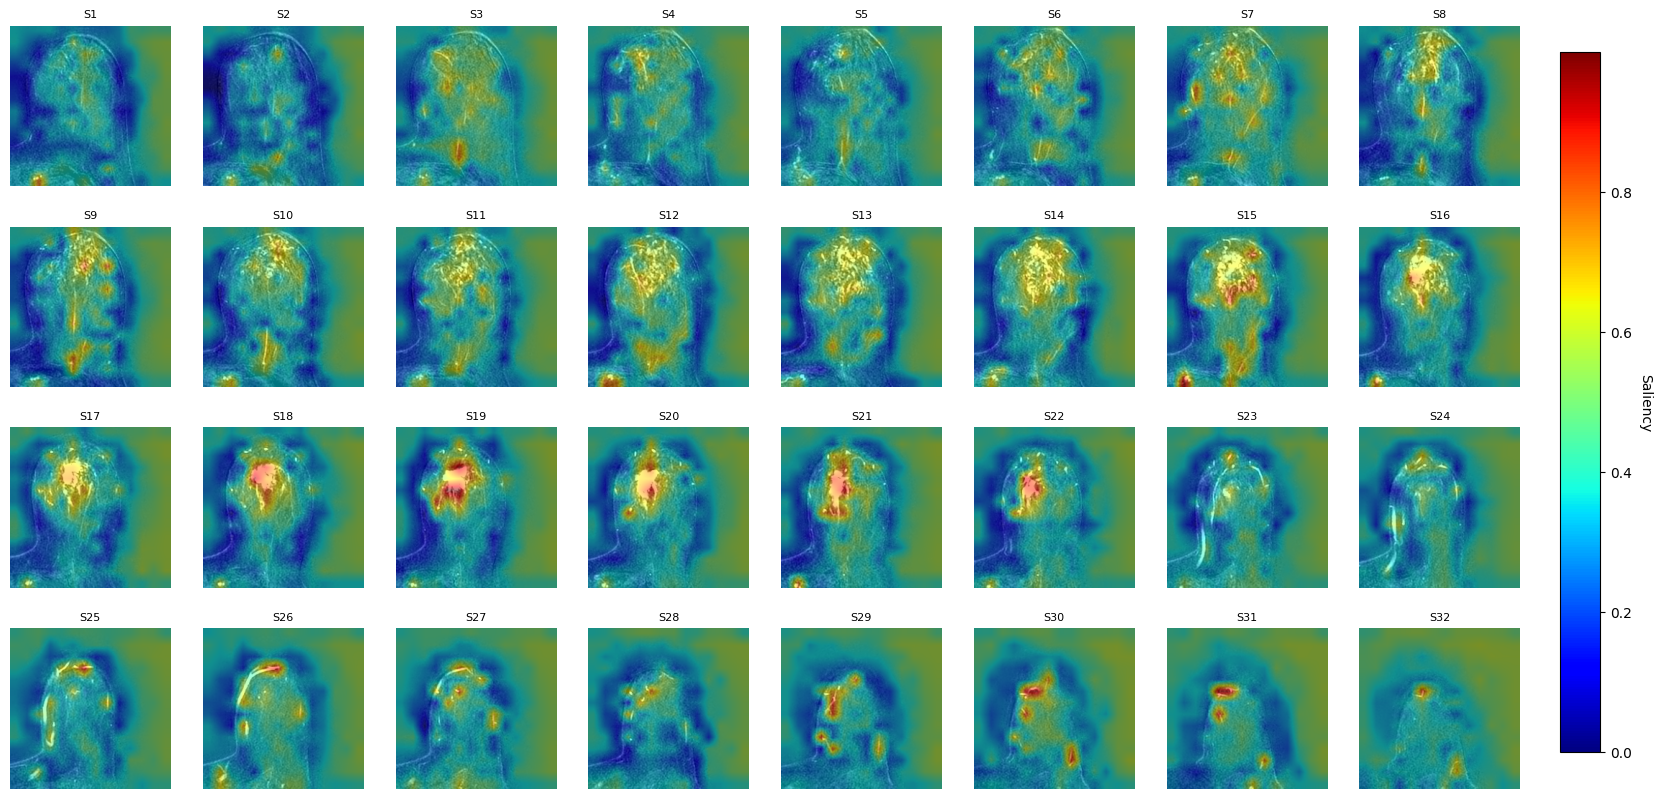

In [34]:
overlays = []
num_slices = batch["source"].shape[2]
volume = batch["source"].squeeze(0).squeeze(0).cpu().numpy()  # (D, H, W)
volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)  # Normalize to [0,1]
print(f"min_volume :={volume.min()}, max_volume :={volume.max()}")
saliency = cam_no_relu_np  # (D, H, W)
print (f"min_saliency :={saliency.min()}, max_saliency :={saliency.max()}")

for i in range(num_slices):
    overlays.append(
        overlay_heatmap(volume[i], saliency[i])
    )

fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(overlays[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
plt.show()
plt.close(fig)

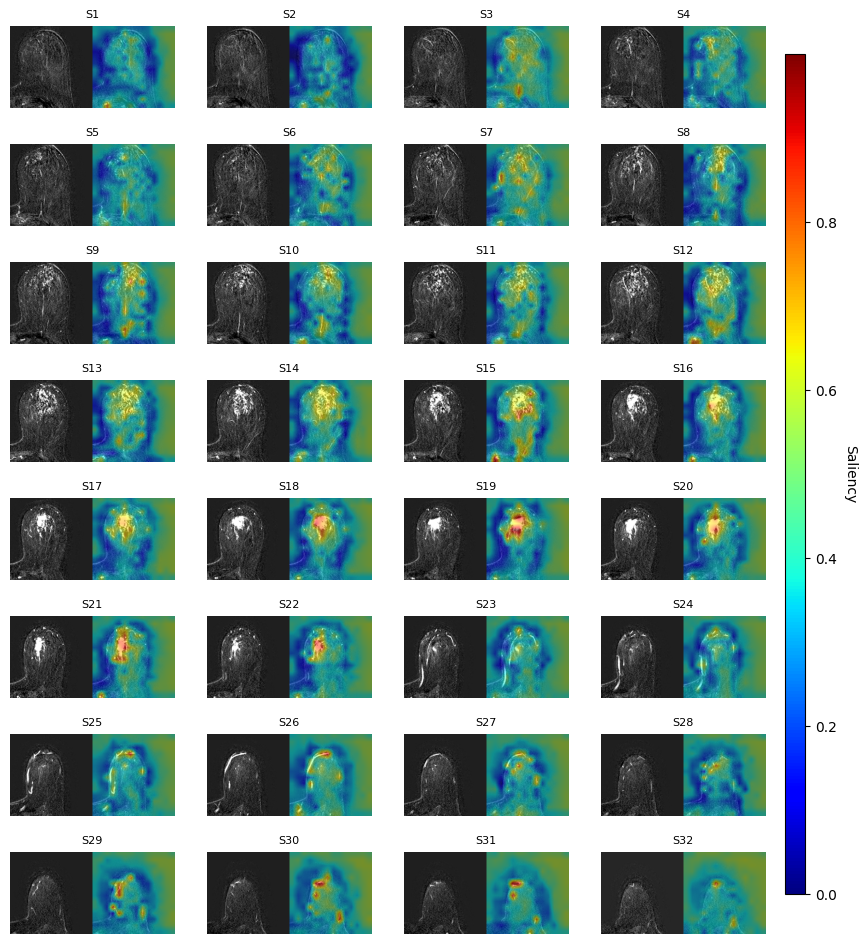

In [35]:
comparisons = []
for i in range(num_slices):

    img = volume[i]
    sal = saliency[i]

    overlay = overlay_heatmap(img, sal)

    img_rgb = np.stack([img]*3, axis=-1)
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)
    img_rgb = np.uint8(255 * img_rgb)

    combined = np.concatenate([img_rgb, overlay], axis=1)
    comparisons.append(combined)

fig, axes = plt.subplots(8, 4, figsize=(10, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(comparisons[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

# fig.suptitle(f"{uid} | {class_name} | {method_name}", fontsize=14)

# comparison_path = os.path.join(
#     class_save_root,
#     f"{uid}_{class_name}_{method_name}_comparison.png"
# )
fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.savefig(comparison_path, dpi=150)
plt.show()
plt.close(fig)

### Try new image

In [36]:
sample = ds[52]   # single sample
uid = sample["uid"]
gt = int(sample["target"])

print("UID:", uid, "GT:", gt)

UID: RUMC_067_left GT: 2


In [37]:
source = sample["source"].unsqueeze(0).to(device)

# logits = model(source)
logits = activations_and_grads(source)
pred_class = logits.argmax(dim=1).item()
class_specific_logits = logits[:,pred_class]

print(f"pred_class : {pred_class}")

pred_class : 2


In [38]:
model.zero_grad()
class_specific_logits.backward()

acts = activations_and_grads.activations  # (B*D, N, C)
grads = activations_and_grads.gradients 

acts = acts[0]
grads = grads[0]

acts, grads = _remove_extra_tokens(acts, grads, source)

weights = grads.mean(dim=(0,1)) # (C)
weights = weights.unsqueeze(0).unsqueeze(1)


cam = (acts * weights).sum(dim=2)  # (B*D, N) 
cam = torch.relu(cam)

h_p = H // patch_size
w_p = W // patch_size
cam = cam.view(B, D, h_p, w_p)  # Reshape from (B*D, N) to (B, D, h_p, w_p)

cam = F.interpolate(
    cam.unsqueeze(1), # add channel dimension for interpolation to (B, 1, D, h_p, w_p)
    size = (D, H, W), # from (B, 1, D, h_p, w_p) to (B, 1, D, H, W)
    mode = 'trilinear',
    align_corners = False).squeeze(1) # remove channel dimension after interpolation

cam = cam.squeeze(0)


# Normalize with min-max normalization per sample
cam = cam - cam.min()
cam = cam / (cam.max() - cam.min() + 1e-8) # add small epsilon to avoid division by zero

cam_np = cam.detach().cpu().numpy()  # (D, H, W)



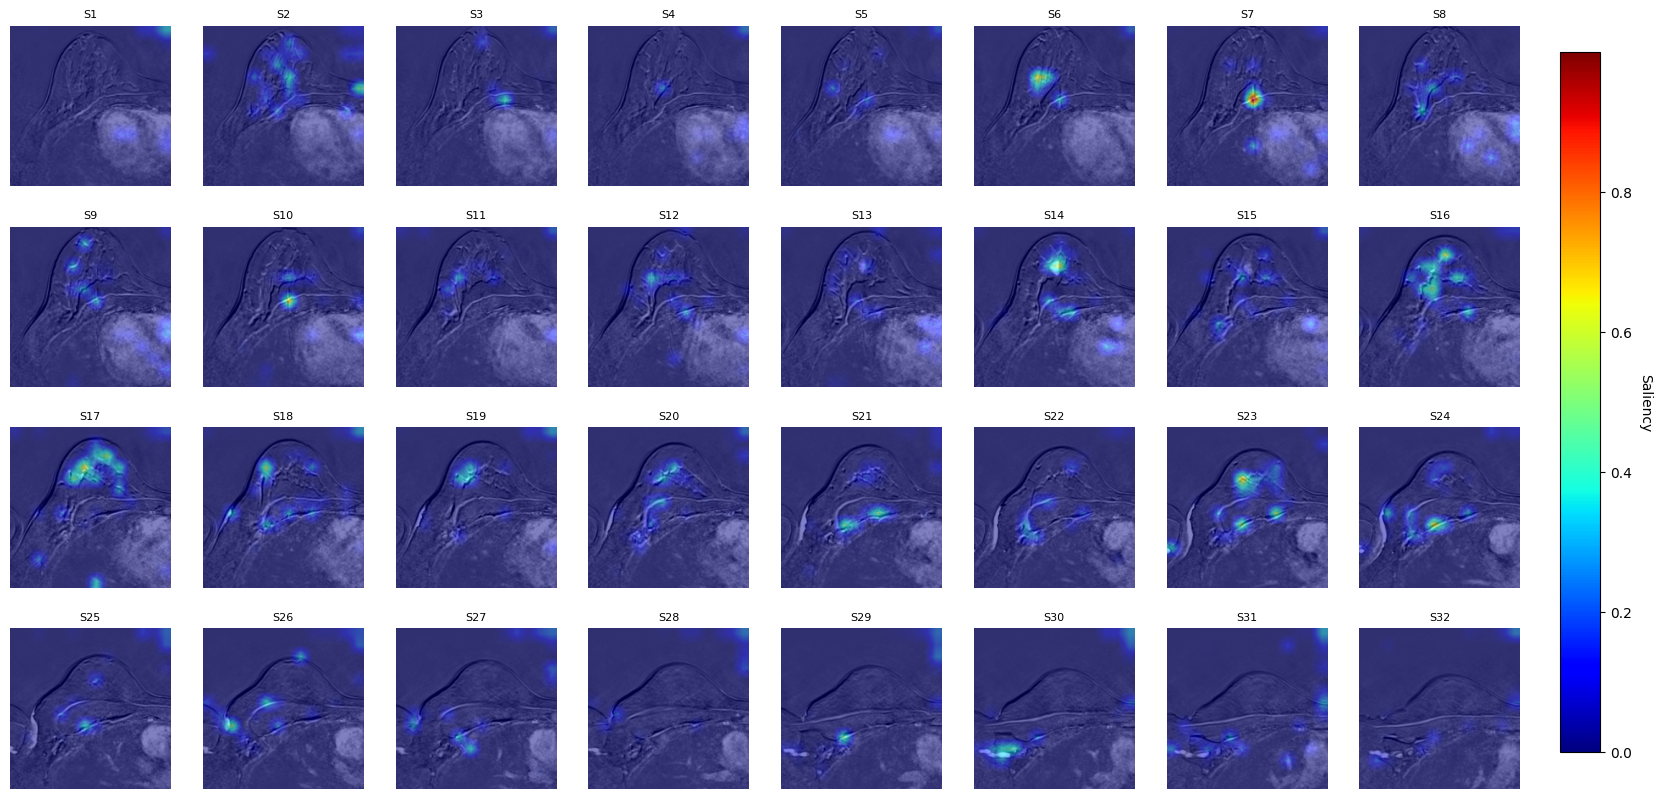

In [39]:
overlays = []
num_slices = source.shape[2]
volume = source.squeeze(0).squeeze(0).cpu().numpy()  # (D, H, W)
volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)  # Normalize to [0,1]
saliency = cam_np # (D, H, W)

for i in range(num_slices):
    overlays.append(
        overlay_heatmap(volume[i], saliency[i])
    )

fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(overlays[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
plt.show()
plt.close(fig)

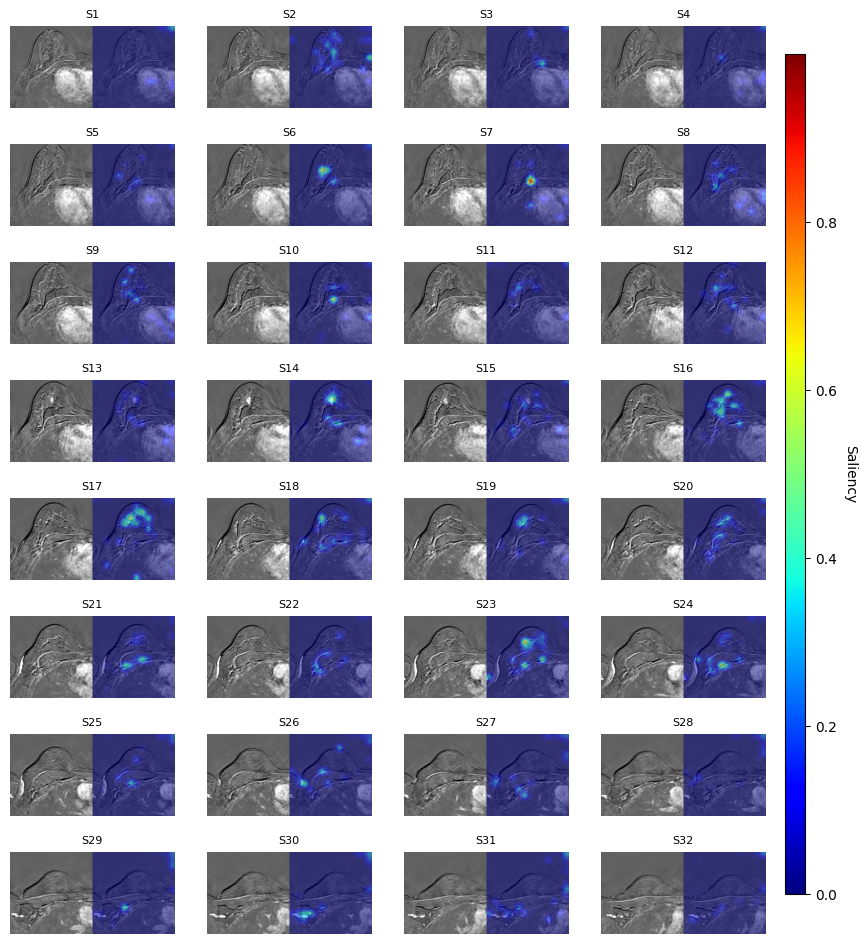

In [40]:
comparisons = []
for i in range(num_slices):

    img = volume[i]
    sal = saliency[i]

    overlay = overlay_heatmap(img, sal)

    img_rgb = np.stack([img]*3, axis=-1)
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() + 1e-8)
    img_rgb = np.uint8(255 * img_rgb)

    combined = np.concatenate([img_rgb, overlay], axis=1)
    comparisons.append(combined)

fig, axes = plt.subplots(8, 4, figsize=(10, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(comparisons[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
plt.show()
plt.close(fig)

## Test Gradient layer

In [41]:
# def _register_hooks(self):

#     # ---------- Patch-level hook ----------
#     # patch_block = self.model.encoder.norm
#     patch_block = self.model.encoder.blocks[-1].norm1

#     def forward_patch(module, input, output):
#         self.patch_activations = output  # (B*D, N, C)

#     def backward_patch(module, grad_input, grad_output):
#         self.patch_gradients = grad_output[0]

#     patch_block.register_forward_hook(forward_patch)
#     patch_block.register_full_backward_hook(backward_patch)

#     # ---------- Slice-level hook ----------
#     slice_block = self.model.slice_fusion.layers[-1].norm1

#     def forward_slice(module, input, output):
#         self.slice_activations = output  # (B, D, C)

#     def backward_slice(module, grad_input, grad_output):
#         self.slice_gradients = grad_output[0]

#     slice_block.register_forward_hook(forward_slice)
#     slice_block.register_full_backward_hook(backward_slice)

In [42]:
# # --------------------------------------------------
# # Core Grad-CAM
# # --------------------------------------------------
# def generate(self, batch, target_class: int):

#     self.model.zero_grad()
#     source = batch["source"].to(self.model.device)

#     B, C, D, H, W = source.shape
#     #patch_size = 14 if using V2
#     patch_size = self.model.encoder.patch_embed.patch_size[0]

#     logits = self.model(source, save_attn=False)
#     score = logits[:, target_class].sum()
#     score.backward()

#     # ===============================
#     # PATCH-LEVEL CAM
#     # ===============================

#     acts = self.patch_activations      # (B*D, N, C) # Already test - not zero
#     grads = self.patch_gradients


#     # ----------------------------------
#     # Remove CLS + extra tokens (robust)
#     # ----------------------------------

#     # detect extra tokens once
#     if not hasattr(self, "num_extra_tokens"):
#         with torch.no_grad():
#             x_enc = source[:1]              # (1,1,D,H,W)
#             x_enc = x_enc[:, :, 0]          # take one slice → (1,1,H,W)
#             x_enc = x_enc.repeat(1, 3, 1, 1)  # → (1,3,H,W)

#             out = self.model.encoder.forward_features(x_enc)

#         if "x_storage_tokens" in out:
#             self.num_extra_tokens = out["x_storage_tokens"].shape[1] #DinoV3 VitB having 5 extra tokens (CLS + 4 storage tokens)
#         elif "x_norm_regtokens" in out:
#             self.num_extra_tokens = out["x_norm_regtokens"].shape[1] #DinoV2 VitS having 5 extra tokens (CLS + 4 reg tokens) if it's use register
#         else:
#             self.num_extra_tokens = 0

#     # remove CLS + extra tokens
#     acts = acts[:, 1 + self.num_extra_tokens:, :]
#     grads = grads[:, 1 + self.num_extra_tokens:, :]

#     weights = grads.mean(dim=1)        # (B*D, C)

#     cam_patch = (acts * weights.unsqueeze(1)).sum(dim=2)                              # (B*D, N_patches)

#     h_p = H // patch_size
#     w_p = W // patch_size

#     cam_patch = cam_patch.view(B, D, h_p, w_p)


#     # ===============================
#     # SLICE-LEVEL CAM
#     # ===============================

#     # remove slice CLS token (there are 33 slices but only 32 have patch-level maps)
#     slice_acts = self.slice_activations[:, 1:, :] # (B, 32, 284)
#     slice_grads = self.slice_gradients[:, 1:, :]

#     slice_weights = slice_grads.mean(dim=1)  # (B, C)

#     cam_slice = (
#         (slice_acts * slice_weights.unsqueeze(1)).sum(dim=-1)
#     )                                        # (B, D)

#     cam_slice = cam_slice / (cam_slice.max(dim=1, keepdim=True)[0] + 1e-8)
#     assert cam_patch.shape[1] == cam_slice.shape[1]


#     # ===============================
#     # HIERARCHICAL COMBINATION
#     # ===============================

#     cam_slice = cam_slice.unsqueeze(-1).unsqueeze(-1)  # (B, D, 1, 1)

#     cam_combined = cam_patch * cam_slice               # weight spatial maps
#     cam_combined = torch.relu(cam_combined)

#     # ===============================
#     # Upsample to voxel resolution
#     # ===============================

#     cam_combined = F.interpolate(
#         cam_combined.unsqueeze(1),
#         size=(D, H, W),
#         mode="trilinear",
#         align_corners=False
#     ).squeeze(1)

#     cam_combined = cam_combined.squeeze(0)

#     cam_combined = cam_combined - cam_combined.min()
#     cam_combined = cam_combined / (cam_combined.max() + 1e-8)

#     return cam_combined

In [43]:
# gradcam = GradCAM_MST(model)

In [44]:
# sal = gradcam.generate(batch, target_class=pred)

In [45]:
# # Inside GradCAM_Slice, but we test externally by re-running backward
# model

# logits = model(batch["source"])
# score = logits[:, pred].sum()
# score.backward()

# acts = gradcam.activations          # [B, N, C]
# grads = gradcam.gradients           # [B, N, C]

# print("CLS grad sum:", grads[:, 0, :].abs().sum().item())
# print("Slice grad sum:", grads[:, 1:, :].abs().sum().item())
